In [ ]:
import os
import sys
from pathlib import Path

# Silence loky physical-core detection warning on Windows without changing notebook logic.
os.environ.setdefault("LOKY_MAX_CPU_COUNT", os.environ.get("NUMBER_OF_PROCESSORS", "1"))

def _find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src" / "cnt_project").exists():
            return p
    raise RuntimeError("Could not locate project root containing src/cnt_project")

PROJECT_ROOT = _find_project_root(Path.cwd())

PROJECT_SRC_ROOT = PROJECT_ROOT / "src"
NOTEBOOK_ROOT = PROJECT_ROOT / "notebooks" / "paper_figures"
LEGACY_NOTEBOOK_ROOT = PROJECT_ROOT / "testing" / "Notebooks" / "Paper_figures"

# Remove existing entries so ordering is deterministic.
for p in [str(PROJECT_SRC_ROOT), str(NOTEBOOK_ROOT), str(LEGACY_NOTEBOOK_ROOT)]:
    if p in sys.path:
        sys.path.remove(p)

# Main package
sys.path.insert(0, str(PROJECT_SRC_ROOT))

# Current notebook helpers
sys.path.insert(0, str(NOTEBOOK_ROOT))

# Legacy helpers only as fallback
sys.path.insert(1, str(LEGACY_NOTEBOOK_ROOT))

In [ ]:
from src.utils.styles import set_figure_style
from src.utils.paths import OUTPUTS, TESTING_PROJECT_ROOT

from src.data.noise_estimation import (
    evaluate_noise_in_folder,
    add_noise_classes,
)

from src.utils.constants import FIG_SIZES

from cnt_project.visualizations.experiments.paper_figures.histograms import (
    plot_noise_histogram,
)

import pandas as pd
import numpy as np
from skimage.filters import threshold_otsu
import matplotlib.pyplot as plt

set_figure_style()

Current font sizes:
Font size: 10.0
Axes labelsize: medium
XTick labelsize: medium
YTick labelsize: medium


In [ ]:
from cnt_project.io.paths import ProjectPaths

P = ProjectPaths.from_here(
    PROJECT_ROOT / "src" / "cnt_project" / "io" / "paths.py"
)

# Train split images (same location as before)
IMAGES_FOLDER = P.images_root("train")

# CSV path for saving noise measurements
NOISE_CSV = IMAGES_FOLDER / "noise_evaluation_results.csv"

# If CSV exists, load it; otherwise compute it
if NOISE_CSV.exists():
    df = pd.read_csv(NOISE_CSV)
    print("Loaded existing noise CSV.")
else:
    print("Computing noise...")
    df = evaluate_noise_in_folder(
        str(IMAGES_FOLDER),
        out_csv=str(NOISE_CSV),
    )

df.head()

Computing noise...


100%|██████████| 200/200 [00:00<00:00, 885.61it/s]


,filename,noise_std
0,1293-22_3_-2_20230306230321.tif,25.203849
1,1293-22_3_0_20230306224436.tif,24.462573
2,400-1093-w11-c1p1-befo3-10sp-15flow_right.tif,5.189030
3,400-1093-w11-c1p2-befo3-20sp-15flow_right.tif,6.671610
4,400-1093-w13-c1-p1-10sp-15flow_right.tif,7.412893


In [4]:
df2 = add_noise_classes(df)
otsu_thresh = threshold_otsu(df['noise_std'].values)

print(f"Otsu Threshold: {otsu_thresh:.2f}")
df2.head()


Otsu Threshold: 14.09


c:\Users\abd93000\PycharmProjects\cnt_project_v2\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\abd93000\PycharmProjects\cnt_project_v2\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\abd93000\AppData\Local\Programs\Python\Python31210\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\abd93000\AppData\Local\Programs\Python\Python31210\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, clo

,filename,noise_std,Noise_Otsu,Noise_KMeans
0,1293-22_3_-2_20230306230321.tif,25.203849,Noisy,Noisy
1,1293-22_3_0_20230306224436.tif,24.462573,Noisy,Noisy
2,400-1093-w11-c1p1-befo3-10sp-15flow_right.tif,5.189030,Clean,Clean
3,400-1093-w11-c1p2-befo3-20sp-15flow_right.tif,6.671610,Clean,Clean
4,400-1093-w13-c1-p1-10sp-15flow_right.tif,7.412893,Clean,Clean


Current font sizes:
Font size: 10.0
Axis labelsize: medium
XTick labelsize: medium
YTick labelsize: medium


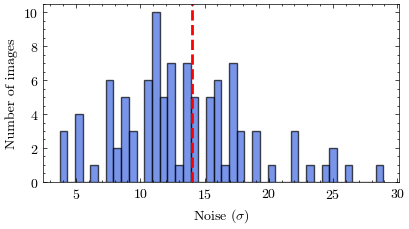

In [5]:
save_path = OUTPUTS["noise"] / "noise_distribution_exact.svg"

plot_noise_histogram(
    df2["noise_std"].values,
    bins=42,
    threshold=14,
    figsize=FIG_SIZES["hist_fig"],
    save_path=save_path
)
